# Predictive Maintenance — Clusteranalyse & 3D-Visualisierung
### Projektarbeit ML · Erweiterung v2 · Alexander Sagert · Juni 2026

> **Companion zum Haupt-Notebook** `14-predictive-maintenance-projektarbeit-AS.ipynb`.
> Hier geht es nicht um die Vorhersage, sondern um das **Sichtbarmachen der Struktur**
> im AI4I-2020-Datensatz: Wo im Merkmalsraum sitzen die Ausfälle? Bilden sich
> natürliche „Betriebszustände"? Welche Cluster sind Risikozonen?

**Inspiriert von der Hierarchie-Clustering-Übung** (Swiss-Roll-3D-Scatter, Dendrogramme,
Methodenvergleich) — übertragen auf echte Maschinendaten.

**Inhalt:**
1. PCA in den 3D-Raum + statischer 3D-Scatter (nach Ausfall & Fehlertyp)
2. Interaktiver, drehbarer 3D-Plot (Plotly → HTML-Export)
3. Hierarchisches Clustering: Dendrogramm (Ward)
4. K-Means im 3D-Raum + Ausfallquote je Cluster (Risikozonen)
5. Methodenvergleich: K-Means vs. Agglomerativ vs. DBSCAN


## 0 · Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (aktiviert 3D-Projektion)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Ausgabeordner für exportierte Grafiken
OUT = Path("visualisierung")
OUT.mkdir(exist_ok=True)
print("Setup ok. Export ->", OUT.resolve())

Setup ok. Export -> C:\Users\Alex\Desktop\Weiterbildung\educx\02_Machine_Learning_und_KI\ML Theorie und Aufgaben\Projektarbeit Predictive Maintenance\visualisierung


### 0.1 · Daten laden & Features bauen
Identisches `build_features` wie im Haupt-Notebook und in `app.py`.

In [2]:
def _resolve(filename: str) -> Path:
    '''Findet eine Datei im Ordner, in ./data oder in Eltern-Ordnern.'''
    here = Path.cwd()
    for c in [here / filename, here / "data" / filename,
              here.parent / filename, here.parent / "data" / filename]:
        if c.exists():
            return c
    for parent in [here, *here.parents]:
        hit = list(parent.glob(f"**/{filename}"))
        if hit:
            return hit[0]
    raise FileNotFoundError(filename)


def build_features(d: pd.DataFrame) -> pd.DataFrame:
    '''Feature Engineering — identisch zum Haupt-Notebook / app.py.'''
    out = pd.DataFrame(index=d.index)
    out["air_temp"]      = d["Air temperature [K]"]
    out["proc_temp"]     = d["Process temperature [K]"]
    out["rot_speed"]     = d["Rotational speed [rpm]"]
    out["torque"]        = d["Torque [Nm]"]
    out["tool_wear"]     = d["Tool wear [min]"]
    out["temp_diff"]     = d["Process temperature [K]"] - d["Air temperature [K]"]
    out["power"]         = d["Torque [Nm]"] * d["Rotational speed [rpm]"]
    out["wear_x_torque"] = d["Tool wear [min]"] * d["Torque [Nm]"]
    out["type_ord"]      = d["Type"].map({"L": 0, "M": 1, "H": 2}).fillna(1)
    return out


def failure_label(row):
    if row["Machine failure"] == 0:
        return "OK"
    for t in ["TWF", "HDF", "PWF", "OSF", "RNF"]:
        if row[t] == 1:
            return t
    return "OK"


df = pd.read_csv(_resolve("ai4i2020.csv"))
df["failure_type"] = df.apply(failure_label, axis=1)
X = build_features(df)
y = df["Machine failure"].astype(int)
print("Daten:", df.shape, "| Ausfallquote: {:.2%}".format(y.mean()))
df[["Type", "Torque [Nm]", "Tool wear [min]", "Machine failure", "failure_type"]].head()

Daten: (10000, 15) | Ausfallquote: 3.39%


,Type,Torque [Nm],Tool wear [min],Machine failure,failure_type
0,M,42.8,0,0,OK
1,L,46.3,3,0,OK
2,L,49.4,5,0,OK
3,L,39.5,7,0,OK
4,L,40.0,9,0,OK


## 1 · PCA in den 3D-Raum
Neun Merkmale lassen sich nicht direkt zeichnen. Wir projizieren sie per **PCA**
(nach Standardisierung) auf die **3 stärksten Hauptkomponenten** und schauen,
wo die Ausfälle im Raum liegen.

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=3, random_state=RANDOM_STATE)
X3 = pca.fit_transform(X_scaled)
evr = pca.explained_variance_ratio_
print("Erklärte Varianz je Komponente:", np.round(evr, 3),
      "| kumuliert: {:.1%}".format(evr.sum()))

lab = [f"PC{i+1} ({evr[i]*100:.0f}%)" for i in range(3)]

Erklärte Varianz je Komponente: [0.335 0.251 0.192] | kumuliert: 77.9%


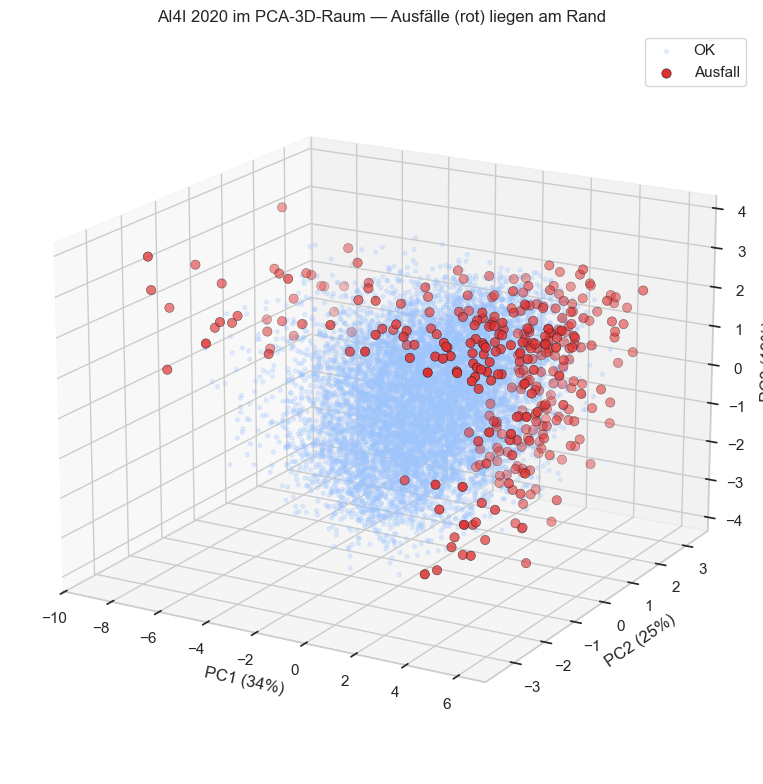

In [4]:
# Statischer 3D-Scatter: OK (blass) vs. Ausfall (rot, größer) — die Ausfälle "leuchten"
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(projection="3d")

ok = y == 0
ax.scatter(X3[ok, 0], X3[ok, 1], X3[ok, 2], c="#9ec5fe", s=8, alpha=0.25, label="OK")
ax.scatter(X3[~ok, 0], X3[~ok, 1], X3[~ok, 2], c="#e03131", s=45,
           edgecolor="k", linewidth=0.4, marker="o", label="Ausfall")
ax.set_xlabel(lab[0]); ax.set_ylabel(lab[1]); ax.set_zlabel(lab[2])
ax.set_title("AI4I 2020 im PCA-3D-Raum — Ausfälle (rot) liegen am Rand")
ax.view_init(elev=18, azim=-60)
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "01_pca_3d_ausfaelle.png", dpi=130, bbox_inches="tight")
plt.show()

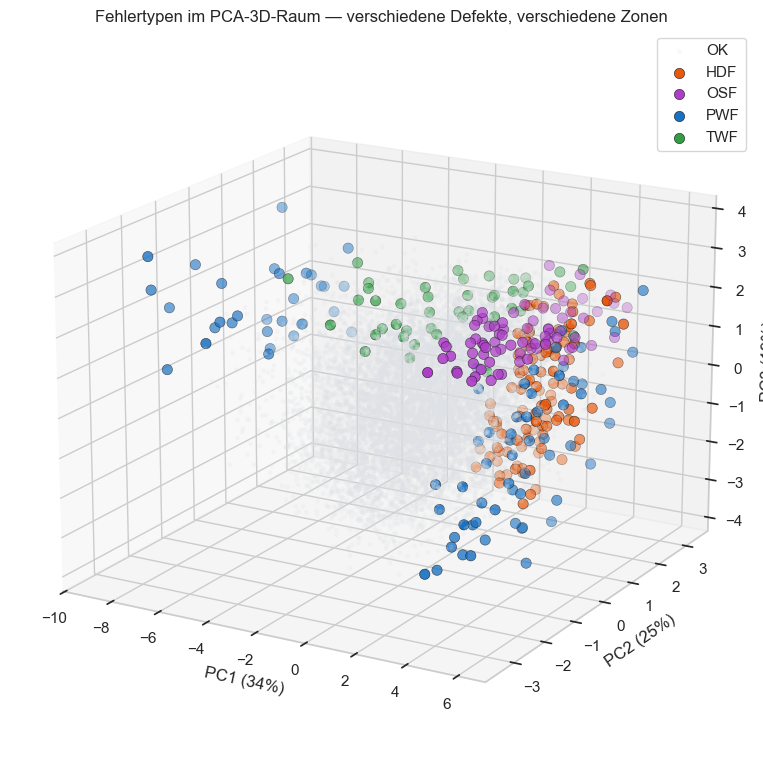

In [5]:
# Gleicher Raum, aber nach FEHLERTYP eingefärbt (nur die Ausfälle)
colors = {"HDF": "#e8590c", "OSF": "#ae3ec9", "PWF": "#1971c2",
          "TWF": "#2f9e44", "RNF": "#f08c00"}
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(projection="3d")
ax.scatter(X3[ok, 0], X3[ok, 1], X3[ok, 2], c="#dee2e6", s=6, alpha=0.15, label="OK")
for t, col in colors.items():
    m = df["failure_type"].values == t
    if m.any():
        ax.scatter(X3[m, 0], X3[m, 1], X3[m, 2], c=col, s=55,
                   edgecolor="k", linewidth=0.4, label=t)
ax.set_xlabel(lab[0]); ax.set_ylabel(lab[1]); ax.set_zlabel(lab[2])
ax.set_title("Fehlertypen im PCA-3D-Raum — verschiedene Defekte, verschiedene Zonen")
ax.view_init(elev=18, azim=-60)
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "02_pca_3d_fehlertypen.png", dpi=130, bbox_inches="tight")
plt.show()

**Diskussion.** Die ersten drei Hauptkomponenten fangen den Großteil der Varianz
ein. Die Ausfälle (rot) sind **nicht zufällig verstreut**, sondern sammeln sich in
Randbereichen des Raums — genau dort, wo Drehmoment, Verschleiß und Leistung extrem
werden. Nach Fehlertyp eingefärbt zeigt sich: **HDF, OSF und PWF besetzen
unterschiedliche Zonen** — physikalisch plausibel, weil ihnen verschiedene
Stress-Ursachen zugrunde liegen.

## 2 · Interaktiver 3D-Plot (drehbar)
Ein statisches Bild zeigt nur einen Blickwinkel. Mit **Plotly** wird der Raum
**drehbar** — man kann die Risikozonen aus jeder Richtung betrachten. Wird als
eigenständige HTML-Datei exportiert (für Präsentation & Repo, offline lauffähig).

In [6]:
import plotly.express as px

# Für Performance/Dateigröße: alle Ausfälle + Stichprobe der OK-Punkte
rng = np.random.default_rng(RANDOM_STATE)
ok_idx = np.where(ok)[0]
ok_sample = rng.choice(ok_idx, size=min(2000, len(ok_idx)), replace=False)
keep = np.concatenate([ok_sample, np.where(~ok)[0]])

plot_df = pd.DataFrame({
    "PC1": X3[keep, 0], "PC2": X3[keep, 1], "PC3": X3[keep, 2],
    "Status": np.where(y.values[keep] == 1, "Ausfall", "OK"),
    "Fehlertyp": df["failure_type"].values[keep],
    "Drehmoment": df["Torque [Nm]"].values[keep],
    "Verschleiß": df["Tool wear [min]"].values[keep],
})

fig = px.scatter_3d(
    plot_df, x="PC1", y="PC2", z="PC3", color="Fehlertyp",
    color_discrete_map={"OK": "#ced4da", "HDF": "#e8590c", "OSF": "#ae3ec9",
                        "PWF": "#1971c2", "TWF": "#2f9e44", "RNF": "#f08c00"},
    hover_data=["Drehmoment", "Verschleiß"], opacity=0.8,
    title="Interaktiver PCA-3D-Raum — nach Fehlertyp (drehbar)")
fig.update_traces(marker=dict(size=3))
fig.update_layout(legend=dict(itemsizing="constant"), height=650)

html_path = OUT / "03_pca_3d_interaktiv.html"
fig.write_html(html_path, include_plotlyjs=True)  # self-contained, offline
print("Interaktiver Plot gespeichert:", html_path)
fig.show()

Interaktiver Plot gespeichert: visualisierung\03_pca_3d_interaktiv.html


> 💡 **Tipp für die Präsentation:** Die Datei `visualisierung/03_pca_3d_interaktiv.html`
> einfach im Browser öffnen und live drehen — das ist der „Wow"-Moment, wenn die
> Ausfall-Cluster aus verschiedenen Winkeln sichtbar werden.

## 3 · Hierarchisches Clustering — Dendrogramm
Hierarchisches Clustering ist **O(n²)** im Speicher — bei 10.000 Punkten zu teuer.
Wir ziehen eine **stratifizierte Stichprobe** (OK-Punkte + alle/viele Ausfälle) und
zeichnen den Ward-Baum, genau wie in der Übung.

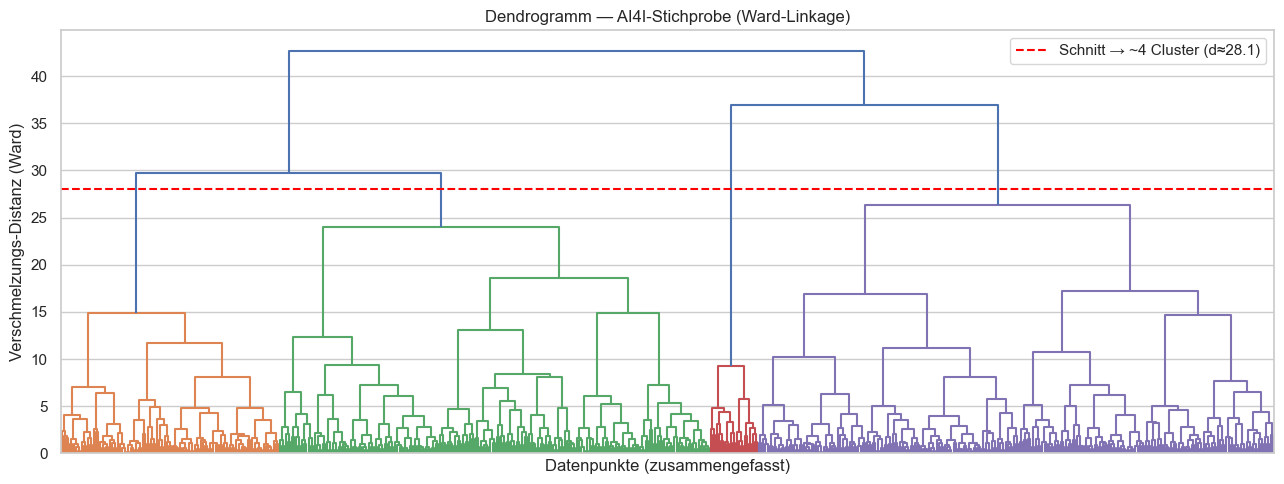

In [7]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Stratifizierte Stichprobe: 400 OK + bis zu 200 Ausfälle
fail_idx = np.where(~ok)[0]
ok_small = rng.choice(ok_idx, size=400, replace=False)
fail_small = rng.choice(fail_idx, size=min(200, len(fail_idx)), replace=False)
samp = np.concatenate([ok_small, fail_small])
Xs_samp = StandardScaler().fit_transform(X.iloc[samp])

Z = linkage(Xs_samp, method="ward")
thr = (Z[-4, 2] + Z[-3, 2]) / 2   # Schnitt für ~4 Cluster

plt.figure(figsize=(13, 5))
dendrogram(Z, no_labels=True, color_threshold=thr)
plt.axhline(thr, color="red", ls="--", label=f"Schnitt → ~4 Cluster (d≈{thr:.1f})")
plt.xlabel("Datenpunkte (zusammengefasst)")
plt.ylabel("Verschmelzungs-Distanz (Ward)")
plt.title("Dendrogramm — AI4I-Stichprobe (Ward-Linkage)")
plt.legend(); plt.tight_layout()
plt.savefig(OUT / "04_dendrogramm.png", dpi=130, bbox_inches="tight")
plt.show()

In [8]:
# Baum auf 4 Cluster schneiden und Ausfallquote je Ast prüfen
cut = fcluster(Z, t=4, criterion="maxclust")
samp_fail = (~ok).astype(int)[samp]
dendro_tab = (pd.DataFrame({"cluster": cut, "ausfall": samp_fail})
                .groupby("cluster")
                .agg(n=("ausfall", "size"), ausfallquote=("ausfall", "mean"))
                .round(3))
display(dendro_tab)
print("-> Äste mit hoher Ausfallquote = Risiko-Cluster im hierarchischen Baum.")

,n,ausfallquote
cluster,,
1,108,0.546
2,213,0.113
3,24,0.875
4,255,0.376


-> Äste mit hoher Ausfallquote = Risiko-Cluster im hierarchischen Baum.


**Diskussion.** Der größte vertikale Sprung im Baum trennt die Daten in wenige
große Äste. Schneidet man auf ~4 Cluster, unterscheiden sich diese **deutlich in
ihrer Ausfallquote** — ein Ast bündelt überproportional viele Ausfälle. Das ist
dieselbe Logik wie bei den Mall-Customers, nur dass der „Kunden-Typ" hier ein
**Maschinen-Betriebszustand** ist.

## 4 · K-Means im 3D-Raum — Risikozonen sichtbar machen
Wir clustern den **vollen** Datensatz mit K-Means (auf den standardisierten
Merkmalen), färben den 3D-Raum nach Cluster und berechnen die **Ausfallquote je
Cluster**. So werden Risikozonen direkt sichtbar.

In [9]:
from sklearn.cluster import KMeans

k = 4
km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
clusters = km.fit_predict(X_scaled)
df["cluster"] = clusters

cluster_tab = (df.groupby("cluster")
                 .agg(n=("Machine failure", "size"),
                      ausfallquote=("Machine failure", "mean"),
                      drehmoment=("Torque [Nm]", "mean"),
                      verschleiss=("Tool wear [min]", "mean"))
                 .round(3)
                 .sort_values("ausfallquote", ascending=False))
display(cluster_tab)

risk_cluster = cluster_tab.index[0]
print(f"-> Cluster {risk_cluster} ist die Hauptrisikozone "
      f"(Ausfallquote {cluster_tab.iloc[0]['ausfallquote']:.1%}).")

,n,ausfallquote,drehmoment,verschleiss
cluster,,,,
3,2741,0.053,42.515,106.579
2,2543,0.053,45.770,166.469
0,2082,0.022,26.510,109.792
1,2634,0.005,42.426,51.428


-> Cluster 3 ist die Hauptrisikozone (Ausfallquote 5.3%).


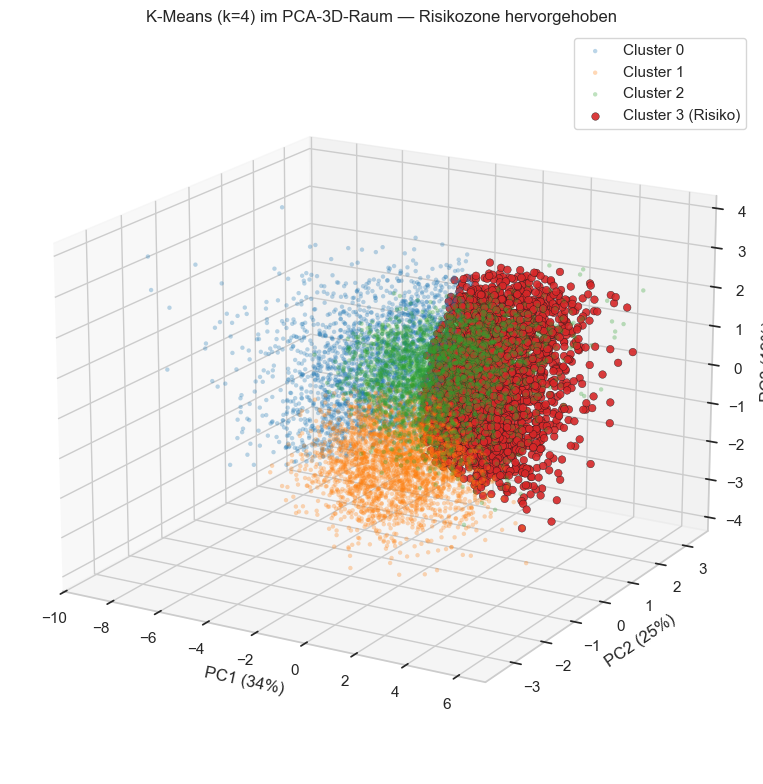

In [10]:
# 3D-Raum nach Cluster eingefärbt; Risiko-Cluster hervorgehoben
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(projection="3d")
palette = sns.color_palette("tab10", k)
for c in range(k):
    m = clusters == c
    is_risk = (c == risk_cluster)
    ax.scatter(X3[m, 0], X3[m, 1], X3[m, 2],
               color=palette[c], s=30 if is_risk else 10,
               alpha=0.9 if is_risk else 0.3,
               edgecolor="k" if is_risk else "none", linewidth=0.3,
               label=f"Cluster {c}" + (" (Risiko)" if is_risk else ""))
ax.set_xlabel(lab[0]); ax.set_ylabel(lab[1]); ax.set_zlabel(lab[2])
ax.set_title(f"K-Means (k={k}) im PCA-3D-Raum — Risikozone hervorgehoben")
ax.view_init(elev=18, azim=-60)
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "05_kmeans_3d_risikozonen.png", dpi=130, bbox_inches="tight")
plt.show()

**Diskussion.** Die Cluster unterscheiden sich klar in ihrer Ausfallquote. Der
Risiko-Cluster ist genau der mit dem **höchsten mittleren Drehmoment und
Verschleiß** — das deckt sich mit der Feature Importance aus dem Haupt-Notebook.
Damit liefert *unüberwachtes* Lernen denselben Befund wie das überwachte Modell:
Hohe mechanische Last = Ausfallrisiko.

## 5 · Methodenvergleich — K-Means vs. Agglomerativ vs. DBSCAN
Wie in der Übung: dieselben Daten, drei Verfahren. Hier auf einer **2D-PCA-Projektion**
der Stichprobe (für DBSCAN gut sichtbar), je eingefärbt nach gefundenem Cluster.

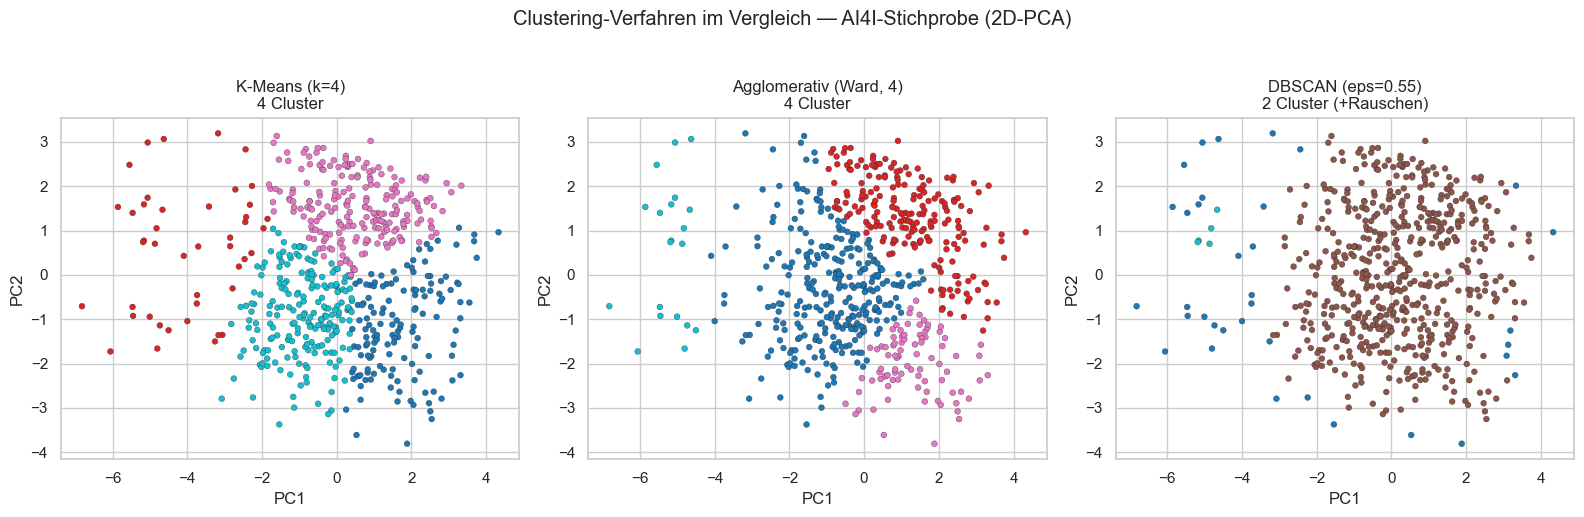

In [11]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors

# 2D-PCA der Stichprobe
X2 = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(Xs_samp)

# DBSCAN-eps heuristisch aus dem k-Distanz-Plot (90. Perzentil der 5.-Nachbar-Distanz)
nn = NearestNeighbors(n_neighbors=5).fit(X2)
dists, _ = nn.kneighbors(X2)
eps = float(np.percentile(dists[:, -1], 90))

models = {
    "K-Means (k=4)": KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE),
    "Agglomerativ (Ward, 4)": AgglomerativeClustering(n_clusters=4, linkage="ward"),
    f"DBSCAN (eps={eps:.2f})": DBSCAN(eps=eps, min_samples=5),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, model) in zip(axes, models.items()):
    cl = model.fit_predict(X2)
    ax.scatter(X2[:, 0], X2[:, 1], c=cl, cmap="tab10", s=18, edgecolor="k", linewidth=0.2)
    n_cl = len(set(cl)) - (1 if -1 in cl else 0)
    ax.set_title(f"{name}\n{n_cl} Cluster" + (" (+Rauschen)" if -1 in cl else ""))
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.suptitle("Clustering-Verfahren im Vergleich — AI4I-Stichprobe (2D-PCA)", y=1.03)
plt.tight_layout()
plt.savefig(OUT / "06_methodenvergleich.png", dpi=130, bbox_inches="tight")
plt.show()

**Diskussion.** **K-Means** und **Ward** liefern kompakte, ähnliche Partitionen —
gut, weil die AI4I-Betriebszustände eher klumpig (konvex) sind. **DBSCAN** trennt
Kern-Betrieb von Randpunkten und markiert Ausreißer als **Rauschen** (`-1`) —
nützlich für **Anomalieerkennung**, aber empfindlich gegenüber `eps`. Fazit wie in
der Übung: Das Verfahren muss zur erwarteten Cluster-**Form** passen; für saubere
Betriebszustände sind K-Means/Ward erste Wahl, für Anomalien DBSCAN.

## Zusammenfassung & Mehrwert fürs Projekt

- **PCA-3D** macht sichtbar, dass Ausfälle **strukturiert am Rand** des Merkmalsraums
  liegen — kein Rauschen, sondern Physik.
- **Fehlertypen** besetzen **unterschiedliche Zonen** → spricht für die Multiklassen-Idee.
- **Hierarchisches & K-Means-Clustering** finden **Risikozonen** rein unüberwacht —
  konsistent mit der Feature Importance des Vorhersagemodells.
- Der **interaktive 3D-Plot** (`visualisierung/03_pca_3d_interaktiv.html`) ist ein
  starkes Präsentations-Asset.

**Exportierte Grafiken** liegen in `visualisierung/` (PNG + HTML) und können direkt
in die Präsentation oder die README eingebunden werden.
